Tableau Dashboard -
Which day contributes more to the sales
which month generates more sales
Total Revenue Per Year
CPI VS UNEMPLOYMENT RATE
Holiday Vs WEEKly Sales

In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose

In [23]:
walmart_df = pd.read_csv('C:/Users/Langa/Desktop/Python/walmart-recruiting-store-sales-forecasting/walmart_combined.csv')

walmart_df.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_x,Dept,Weekly_Sales,IsHoliday_y
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,1.0,24924.50,False
1,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,2.0,50605.27,False
2,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,3.0,13740.12,False
3,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,4.0,39954.04,False
4,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,5.0,32229.38,False


In [24]:
print("Walmart Data Information")
print(walmart_df.info())

Walmart Data Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 423325 entries, 0 to 423324
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         423325 non-null  int64  
 1   Date          423325 non-null  object 
 2   Temperature   423325 non-null  float64
 3   Fuel_Price    423325 non-null  float64
 4   MarkDown1     152433 non-null  float64
 5   MarkDown2     112532 non-null  float64
 6   MarkDown3     138658 non-null  float64
 7   MarkDown4     136466 non-null  float64
 8   MarkDown5     153187 non-null  float64
 9   CPI           422740 non-null  float64
 10  Unemployment  422740 non-null  float64
 11  IsHoliday_x   423325 non-null  bool   
 12  Dept          421570 non-null  float64
 13  Weekly_Sales  421570 non-null  float64
 14  IsHoliday_y   421570 non-null  object 
dtypes: bool(1), float64(11), int64(1), object(2)
memory usage: 45.6+ MB
None


In [25]:
duplicates = walmart_df.duplicated()
print(duplicates)

0         False
1         False
2         False
3         False
4         False
          ...  
423320    False
423321    False
423322    False
423323    False
423324    False
Length: 423325, dtype: bool


In [26]:
# Drop the duplicate column created during merge
walmart_df = walmart_df.drop(columns=["IsHoliday_x"])

# Rename IsHoliday_y back to IsHoliday
walmart_df = walmart_df.rename(columns={"IsHoliday_y": "IsHoliday"})

# Convert IsHoliday column to string type (without overwriting the whole DataFrame)
walmart_df["IsHoliday"] = walmart_df["IsHoliday"].astype(str)

print(walmart_df.head())


   Store        Date  Temperature  Fuel_Price  MarkDown1  MarkDown2  \
0      1  2010-02-05        42.31       2.572        NaN        NaN   
1      1  2010-02-05        42.31       2.572        NaN        NaN   
2      1  2010-02-05        42.31       2.572        NaN        NaN   
3      1  2010-02-05        42.31       2.572        NaN        NaN   
4      1  2010-02-05        42.31       2.572        NaN        NaN   

   MarkDown3  MarkDown4  MarkDown5         CPI  Unemployment  Dept  \
0        NaN        NaN        NaN  211.096358         8.106   1.0   
1        NaN        NaN        NaN  211.096358         8.106   2.0   
2        NaN        NaN        NaN  211.096358         8.106   3.0   
3        NaN        NaN        NaN  211.096358         8.106   4.0   
4        NaN        NaN        NaN  211.096358         8.106   5.0   

   Weekly_Sales IsHoliday  
0      24924.50     False  
1      50605.27     False  
2      13740.12     False  
3      39954.04     False  
4      32229

In [27]:
walmart_df.describe()

,Store,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Dept,Weekly_Sales
count,423325.000000,423325.000000,423325.000000,152433.000000,112532.000000,138658.000000,136466.000000,153187.000000,422740.000000,422740.000000,421570.000000,421570.000000
mean,22.203860,60.067140,3.361933,7246.604247,3337.597289,1449.098932,3382.019834,4618.743783,171.218863,7.957296,44.260317,15981.258123
std,12.786244,18.452599,0.458038,8319.906707,9461.265420,9674.705234,6306.728468,6258.233496,39.167088,1.863433,30.492054,22711.183519
min,1.000000,-7.290000,2.472000,-2781.450000,-265.760000,-179.260000,0.220000,-185.170000,126.064000,3.684000,1.000000,-4988.940000
25%,11.000000,46.670000,2.935000,2230.800000,42.000000,5.140000,500.910000,1863.720000,132.022667,6.891000,18.000000,2079.650000
50%,22.000000,62.070000,3.452000,5336.520000,194.670000,24.830000,1465.540000,3340.020000,182.350989,7.866000,37.000000,7612.030000
75%,33.000000,74.260000,3.738000,9210.900000,1943.200000,104.500000,3592.000000,5535.130000,212.512605,8.567000,74.000000,20205.852500
max,45.000000,101.950000,4.468000,103184.980000,104519.540000,149483.310000,67474.850000,771448.100000,228.976456,14.313000,99.000000,693099.360000


In [28]:
print(walmart_df.isnull().sum())

Store                0
Date                 0
Temperature          0
Fuel_Price           0
MarkDown1       270892
MarkDown2       310793
MarkDown3       284667
MarkDown4       286859
MarkDown5       270138
CPI                585
Unemployment       585
Dept              1755
Weekly_Sales      1755
IsHoliday            0
dtype: int64


In [29]:
features = {
    'MarkDown1'    : 'MarkDown 1 — Promotional Discount',
    'MarkDown2'    : 'MarkDown 2 — Promotional Discount',
    'MarkDown3'    : 'MarkDown 3 — Promotional Discount',
    'MarkDown4'    : 'MarkDown 4 — Promotional Discount',
    'MarkDown5'    : 'MarkDown 5 — Promotional Discount',
    'CPI'          : 'Consumer Price Index (CPI)',
    'Unemployment' : 'Regional Unemployment Rate (%)',
    'Weekly_Sales' : 'Weekly Sales (USD)',
}

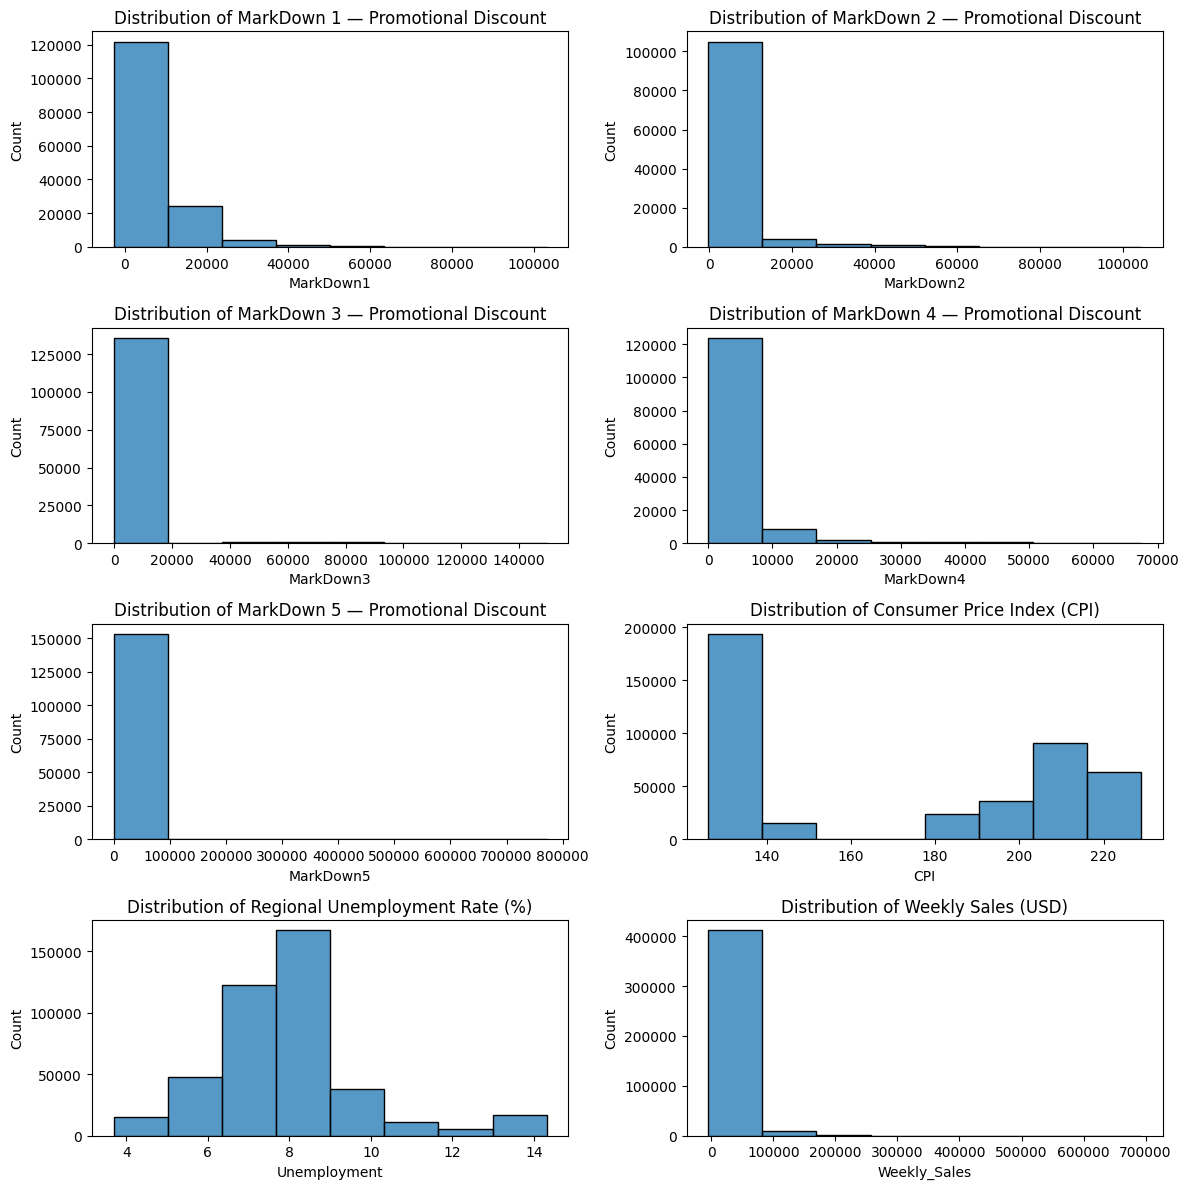

In [ ]:
# Filter features based on available columns in the data frame
feature = {feature: title for feature, title in features.items() if feature in walmart_df.columns}

# Determine the number of rows needed for the subplots
num_features = len(feature)
rows = (num_features // 2) + (num_features % 2 > 0)

# create subplots
fig, axes = plt.subplots(nrows=rows, ncols=2, figsize=(12, rows * 3))
axes = axes.flatten()  # Flatten the axes array for easier indexing

for i, (feat, title) in enumerate(feature.items()):
    sns.histplot(walmart_df[feat], bins=8, ax=axes[i])
    axes[i].set_title(f"Distribution of {title}")

# Remove any unused subplot spaces
for j in range(i + 1, len(axes)):
  fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [31]:
# Convert IsHoliday from string to numeric (0/1)
walmart_df["IsHoliday"] = walmart_df["IsHoliday"].map({"False": 0, "True": 1})


In [32]:
# Step 1: Drop rows where both Dept and Weekly_Sales are missing (useless observations)
walmart_df = walmart_df.dropna(subset=['Dept', 'Weekly_Sales'])

# Step 2: Markdowns - fill with 0 (no promotion occurred)
markdown_cols = ["MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]
walmart_df[markdown_cols] = walmart_df[markdown_cols].fillna(0)

# Step 3: Continuous features - fill with median per store
continuous_cols = ["CPI", "Unemployment"]
walmart_df[continuous_cols] = walmart_df.groupby("Store")[continuous_cols].transform(
    lambda x: x.fillna(x.median())
)

# Step 4: Categorical features - fill with mode per store
walmart_df["IsHoliday"] = walmart_df.groupby("Store")["IsHoliday"].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else x)
)

# Step 5: Confirm everything is clean
print(walmart_df.isna().sum())
print(f"Remaining rows: {len(walmart_df)}")

Store           0
Date            0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
Dept            0
Weekly_Sales    0
IsHoliday       0
dtype: int64
Remaining rows: 421570


In [33]:
# Keep a clean copy for decomposition and stationarity testing
walmart_df_clean = walmart_df.copy()

## **__FEATURE ENGINEERING__**

In [ ]:
# Sort first - critical for correct rolling calculations
walmart_df = walmart_df.sort_values(['Store', 'Dept', 'Date'])

# Rolling averages grouped by Store and Dept
def rolling_averages(df, windows=[5, 10, 20, 52]):
    '''
    Adds rolling mean and std to the dataframe.
    Grouped by Store and Dept to avoid cross-store contamination.
    windows: List of window sizes (in weeks)
    '''
    df = df.copy()

    for window in windows:
        df[f'rolling_mean_{window}'] = (
            df.groupby(['Store', 'Dept'])['Weekly_Sales']
            .transform(lambda x: x.rolling(window=window).mean())
        )
        df[f'rolling_std_{window}'] = (
            df.groupby(['Store', 'Dept'])['Weekly_Sales']
            .transform(lambda x: x.rolling(window=window).std())
        )
        df = df.dropna()
    return df

walmart_df = rolling_averages(walmart_df)

# Check
print(walmart_df[['Store', 'Dept', 'Date', 'Weekly_Sales',
                   'rolling_mean_5', 'rolling_mean_52']].head(20))

      Store  Dept        Date  Weekly_Sales  rolling_mean_5  rolling_mean_52
5940      1   1.0  2011-09-09      17746.68       15358.070     22754.394038
6012      1   1.0  2011-09-16      18535.48       16157.208     22738.648846
6083      1   1.0  2011-09-23      17859.30       16791.220     22733.586923
6155      1   1.0  2011-09-30      18337.68       17551.282     22699.807885
6227      1   1.0  2011-10-07      20797.58       18655.344     22649.991538
6299      1   1.0  2011-10-14      23077.55       19721.518     22574.976346
6371      1   1.0  2011-10-21      23351.80       20684.782     22532.837115
6443      1   1.0  2011-10-28      31579.90       23428.902     22397.048077
6515      1   1.0  2011-11-04      39886.06       27738.578     22505.647692
6587      1   1.0  2011-11-11      18689.54       27316.970     22489.112115
6659      1   1.0  2011-11-18      19050.66       26511.592     22479.454808
6731      1   1.0  2011-11-25      20911.25       26023.482     22519.665577

In [35]:
# Step 4: Date features
walmart_df["Date"] = pd.to_datetime(walmart_df["Date"], errors="coerce")

walmart_df["month"]       = walmart_df["Date"].dt.month
walmart_df["day"]         = walmart_df["Date"].dt.day
walmart_df["year"]        = walmart_df["Date"].dt.year
walmart_df["week"]        = walmart_df["Date"].dt.isocalendar().week.astype(int)
walmart_df["quarter"]     = walmart_df["Date"].dt.quarter
walmart_df["day_of_week"] = walmart_df["Date"].dt.dayofweek

# Step 5: Confirm the new columns
print(walmart_df[['Date', 'month', 'day', 'year', 'week', 'quarter', 'day_of_week']].head(10))
print(f"\nShape: {walmart_df.shape}")

           Date  month  day  year  week  quarter  day_of_week
5940 2011-09-09      9    9  2011    36        3            4
6012 2011-09-16      9   16  2011    37        3            4
6083 2011-09-23      9   23  2011    38        3            4
6155 2011-09-30      9   30  2011    39        3            4
6227 2011-10-07     10    7  2011    40        4            4
6299 2011-10-14     10   14  2011    41        4            4
6371 2011-10-21     10   21  2011    42        4            4
6443 2011-10-28     10   28  2011    43        4            4
6515 2011-11-04     11    4  2011    44        4            4
6587 2011-11-11     11   11  2011    45        4            4

Shape: (169429, 28)


In [36]:
walmart_df.head(10)

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,...,rolling_mean_20,rolling_std_20,rolling_mean_52,rolling_std_52,month,day,year,week,quarter,day_of_week
5940,1,2011-09-09,76.00,3.546,0.0,0.00,0.00,0.00,0.00,215.861056,...,17184.2405,5868.329883,22754.394038,10115.096486,9,9,2011,36,3,4
6012,1,2011-09-16,79.94,3.526,0.0,0.00,0.00,0.00,0.00,216.041053,...,16035.3950,1411.954361,22738.648846,10121.128407,9,16,2011,37,3,4
6083,1,2011-09-23,75.80,3.467,0.0,0.00,0.00,0.00,0.00,216.375825,...,15921.4505,1126.539248,22733.586923,10123.547893,9,23,2011,38,3,4
6155,1,2011-09-30,79.69,3.355,0.0,0.00,0.00,0.00,0.00,216.710597,...,15976.5770,1217.510464,22699.807885,10135.450857,9,30,2011,39,3,4
6227,1,2011-10-07,69.31,3.285,0.0,0.00,0.00,0.00,0.00,217.045368,...,16259.6170,1607.529667,22649.991538,10138.367566,10,7,2011,40,4,4
6299,1,2011-10-14,71.74,3.274,0.0,0.00,0.00,0.00,0.00,217.355273,...,16626.4145,2207.927602,22574.976346,10120.128389,10,14,2011,41,4,4
6371,1,2011-10-21,63.71,3.353,0.0,0.00,0.00,0.00,0.00,217.515976,...,16972.2970,2669.763365,22532.837115,10112.086193,10,21,2011,42,4,4
6443,1,2011-10-28,66.57,3.372,0.0,0.00,0.00,0.00,0.00,217.676679,...,17757.1160,4200.895298,22397.048077,9937.440122,10,28,2011,43,4,4
6515,1,2011-11-04,54.98,3.332,0.0,0.00,0.00,0.00,0.00,217.837382,...,19002.5145,6432.850450,22505.647692,10098.933936,11,4,2011,44,4,4
6587,1,2011-11-11,59.11,3.297,10382.9,6115.67,215.07,2406.62,6551.42,217.998085,...,19152.8510,6386.149599,22489.112115,10104.571669,11,11,2011,45,4,4


## __Data Visualization__ ##

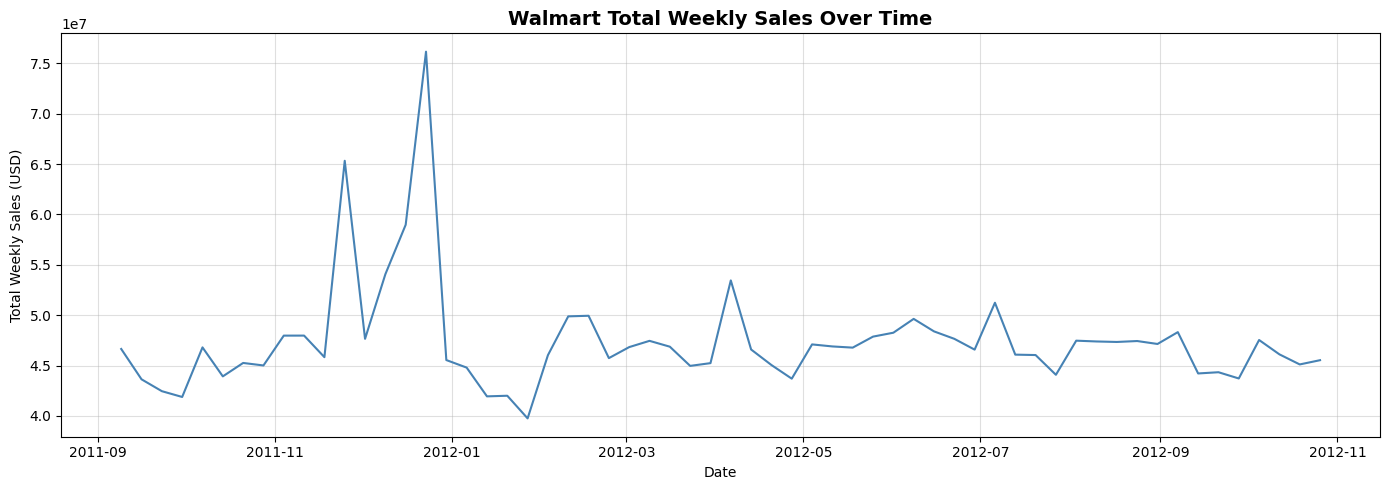

In [37]:
# Aggregate total weekly sales across all stores and departments
weekly_total = walmart_df.groupby('Date')['Weekly_Sales'].sum().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(weekly_total['Date'], weekly_total['Weekly_Sales'], color='steelblue', linewidth=1.5)
plt.title("Walmart Total Weekly Sales Over Time", fontsize=14, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Total Weekly Sales (USD)")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

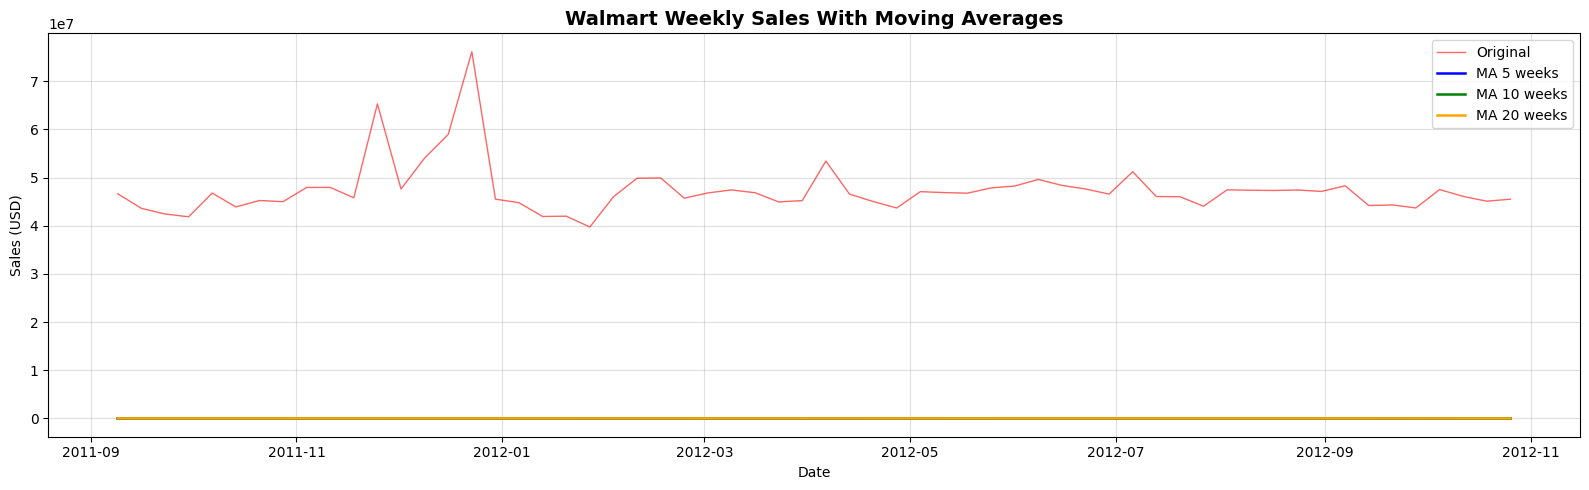

In [ ]:
# Aggregate by date
weekly_total = walmart_df.groupby('Date').agg(
    Weekly_Sales   = ('Weekly_Sales', 'sum'),
    rolling_mean_5 = ('rolling_mean_5', 'mean'),
    rolling_mean_10= ('rolling_mean_10', 'mean'),
    rolling_mean_20= ('rolling_mean_20', 'mean')
).reset_index()

# Plot
plt.figure(figsize=(16, 5))
plt.plot(weekly_total['Date'], weekly_total['Weekly_Sales'],
         label="Original", color="red", linewidth=1, alpha=0.6)
plt.plot(weekly_total['Date'], weekly_total['rolling_mean_5'],
         label="MA 5 weeks", color="blue", linewidth=1.8)
plt.plot(weekly_total['Date'], weekly_total['rolling_mean_10'],
         label="MA 10 weeks", color="green", linewidth=1.8)
plt.plot(weekly_total['Date'], weekly_total['rolling_mean_20'],
         label="MA 20 weeks", color="orange", linewidth=1.8)

plt.title("Walmart Weekly Sales With Moving Averages", fontsize=14, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Sales (USD)")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## __Testing Stationarity__ ##

In [39]:
def test_stationarity(series, label="Series"):
    """
    Performs both ADF and KPSS tests to fully assess stationarity.
    ADF  — null hypothesis: series is NOT stationary
    KPSS — null hypothesis: series IS stationary

    Parameters:
        series (pd.Series) : Time series data.
        label  (str)       : Name of the series for display purposes.

    Returns:
        bool: True if both tests agree series is stationary, False otherwise.
    """
    if series is None or series.empty:
        print("Error: Input series is empty.")
        return False

    if series.nunique() == 1:
        print("Error: Input series is constant.")
        return False

    print(f"\n{'='*50}")
    print(f"Stationarity Tests — {label}")
    print(f"{'='*50}")

    # ── ADF Test ──────────────────────────────────────
    print("\n[ ADF Test ]")
    print("H0: Series is NOT stationary (unit root present)")
    adft = adfuller(series, autolag="AIC")
    adf_output = pd.Series(
        adft[0:4],
        index=["Test Statistic", "p-value", "Lags Used", "Observations Used"]
    )
    for key, value in adft[4].items():
        adf_output[f"Critical Value ({key})"] = value
    print(adf_output)

    adf_stationary = adft[1] <= 0.05
    if adf_stationary:
        print("ADF: Reject H0 — evidence of stationarity")
    else:
        print("ADF: Fail to reject H0 — evidence of non-stationarity")

    # ── KPSS Test ─────────────────────────────────────
    print("\n[ KPSS Test ]")
    print("H0: Series IS stationary")
    kpsst = kpss(series, regression="c", nlags="auto")
    kpss_output = pd.Series(
        [kpsst[0], kpsst[1], kpsst[2]],
        index=["Test Statistic", "p-value", "Lags Used"]
    )
    for key, value in kpsst[3].items():
        kpss_output[f"Critical Value ({key})"] = value
    print(kpss_output)

    kpss_stationary = kpsst[1] >= 0.05
    if kpss_stationary:
        print("✓ KPSS: Fail to reject H0 — evidence of stationarity")
    else:
        print("✗ KPSS: Reject H0 — evidence of non-stationarity")

    # ── Combined Conclusion ───────────────────────────
    print(f"\n{'─'*50}")
    print("CONCLUSION:")
    if adf_stationary and kpss_stationary:
        print("Both tests agree: Series IS stationary")
    elif not adf_stationary and not kpss_stationary:
        print("Both tests agree: Series is NOT stationary")
        print("  Action: Apply differencing")
    elif adf_stationary and not kpss_stationary:
        print("Trend stationary: Series has a deterministic trend")
        print("  Action: Detrend the series")
    else:
        print("Difference stationary: Series has a stochastic trend")
        print("  Action: Apply differencing")
    print(f"{'─'*50}")

    return adf_stationary and kpss_stationary


# Call it on your aggregated weekly sales
weekly_total = walmart_df.groupby('Date')['Weekly_Sales'].sum().sort_index()
is_stationary = test_stationarity(weekly_total, label="Total Weekly Sales")


Stationarity Tests — Total Weekly Sales

[ ADF Test ]
H0: Series is NOT stationary (unit root present)
Test Statistic          -3.686609
p-value                  0.004306
Lags Used                4.000000
Observations Used       55.000000
Critical Value (1%)     -3.555273
Critical Value (5%)     -2.915731
Critical Value (10%)    -2.595670
dtype: float64
ADF: Reject H0 — evidence of stationarity

[ KPSS Test ]
H0: Series IS stationary
Test Statistic           0.115979
p-value                  0.100000
Lags Used                3.000000
Critical Value (10%)     0.347000
Critical Value (5%)      0.463000
Critical Value (2.5%)    0.574000
Critical Value (1%)      0.739000
dtype: float64
✓ KPSS: Fail to reject H0 — evidence of stationarity

──────────────────────────────────────────────────
CONCLUSION:
Both tests agree: Series IS stationary
──────────────────────────────────────────────────


C:\Users\Langa\AppData\Local\Temp\ipykernel_26552\1812924527.py:47: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpsst = kpss(series, regression="c", nlags="auto")


In [40]:
# Aggregate first
weekly_total = (
    walmart_df_clean
    .groupby('Date')['Weekly_Sales']
    .sum()
    .sort_index()
)

print(f"Weeks available: {len(weekly_total)}")

Weeks available: 143


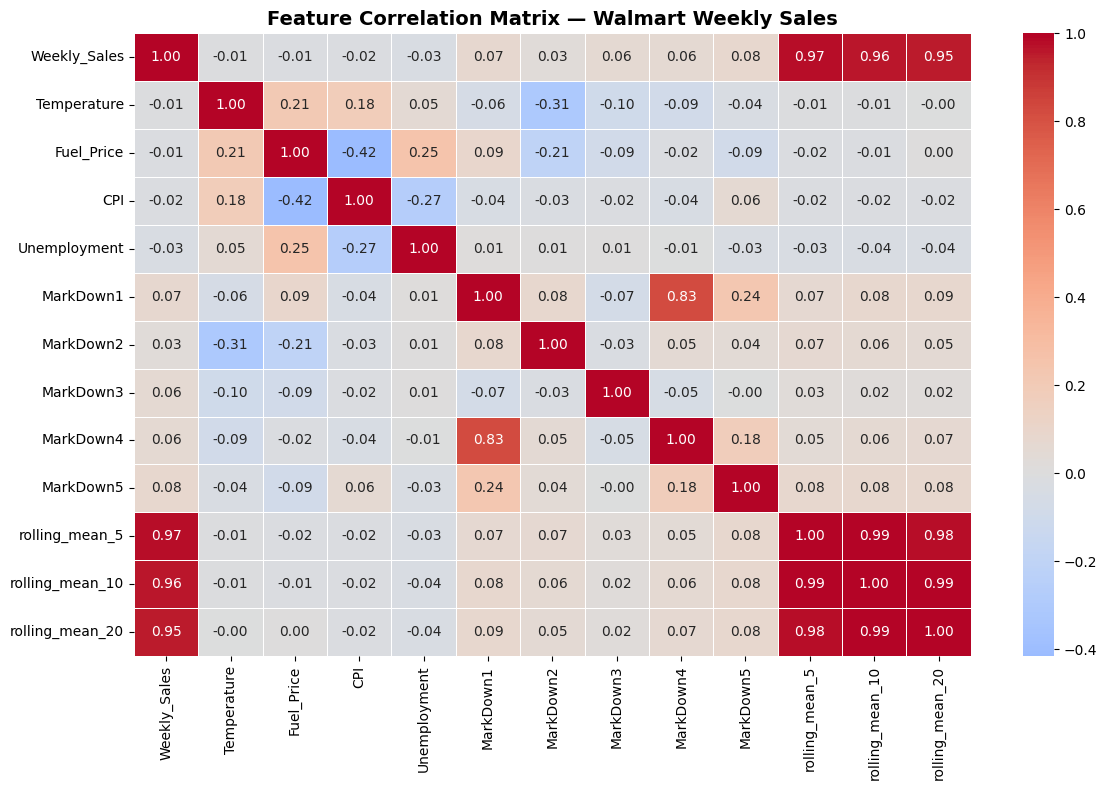

In [ ]:
corr_cols = [
    'Weekly_Sales', 'Temperature', 'Fuel_Price',
    'CPI', 'Unemployment', 'MarkDown1', 'MarkDown2',
    'MarkDown3', 'MarkDown4', 'MarkDown5',
    'rolling_mean_5', 'rolling_mean_10', 'rolling_mean_20'
]

corr_matrix = walmart_df[corr_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)
plt.title("Feature Correlation Matrix — Walmart Weekly Sales", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

corr_matrix.to_csv("walmart_correlation_matrics.csv")

The correlation heatmap reveals three distinct groups of features:

**_①  HIGH CORRELATION with Weekly_Sales_**
   Rolling_mean_5 (0.97), Rolling_mean_10 (0.96), Rolling_mean_20 (0.95)
   → Expected — rolling averages are derived from sales itself.
   → Useful for modelling but not evidence of external causation.

**_② NEAR-ZERO CORRELATION with Weekly_Sales_**
   Temperature, Fuel_Price, CPI, Unemployment (−0.03 to −0.02)
   → Weak linear relationship does not rule out lagged causal effects.
   → Granger causality testing required before excluding these features.

**_③ NOTABLE INTER-FEATURE CORRELATIONS_**
   MarkDown1 & MarkDown4 (0.83) → Multicollinearity risk in modelling
   Rolling means with each other (0.98–0.99) → Redundant information
   Fuel_Price & CPI (−0.42) → Inverse macroeconomic relationship

**__Given the weak linear correlations between external features and weekly sales, we turn to time series decomposition to identify what is actually driving sales variation.__**

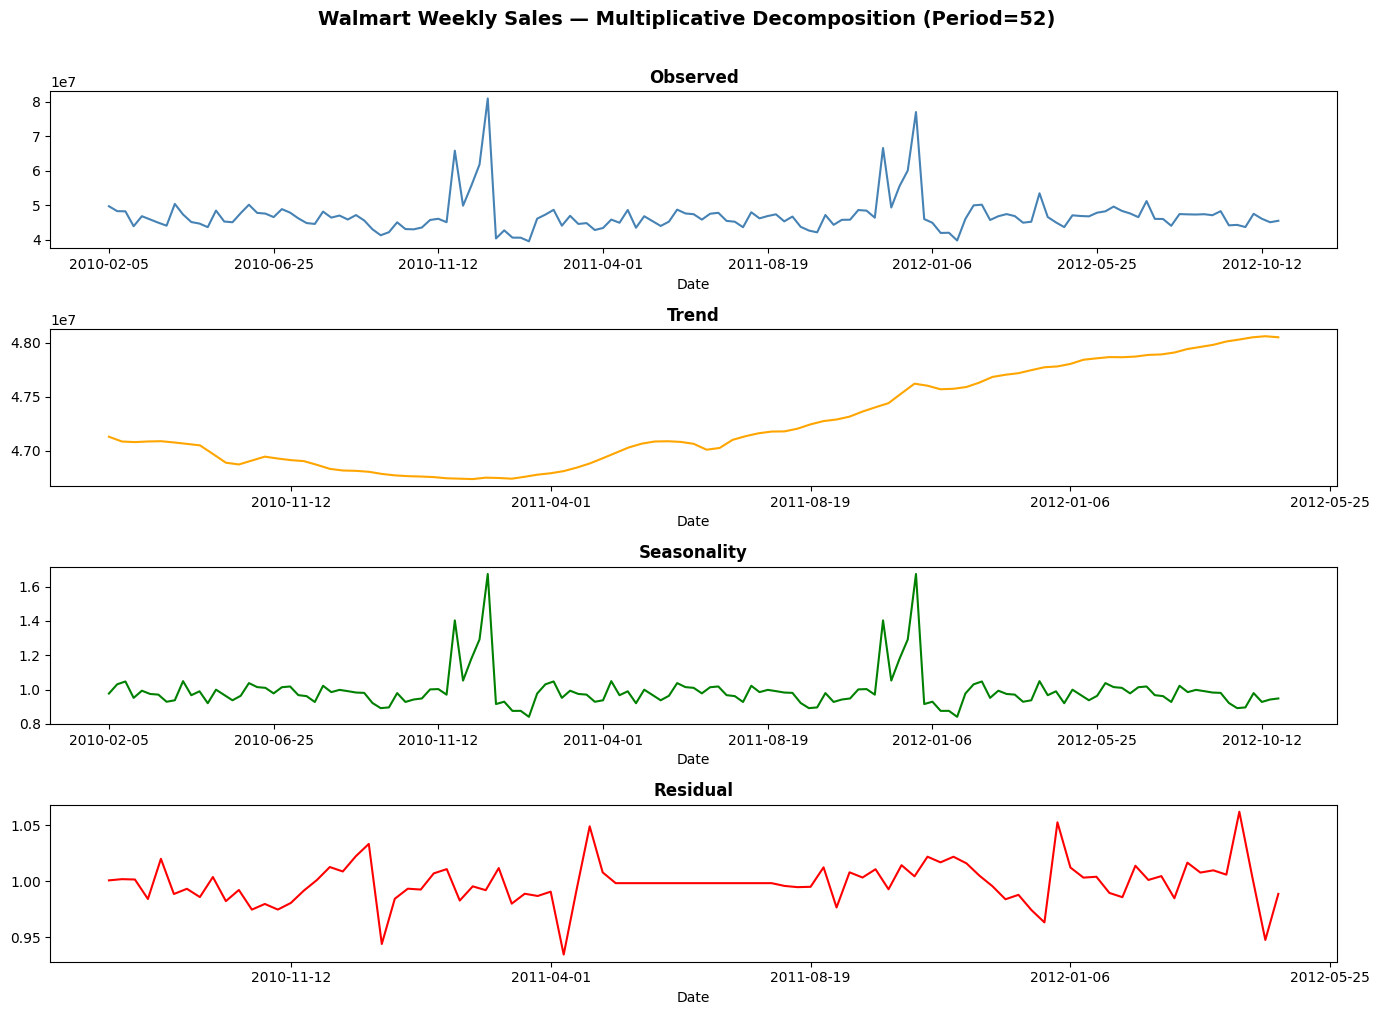

In [ ]:
decomposition = seasonal_decompose(weekly_total, model='multiplicative', period=52)
fig, axes = plt.subplots(4, 1, figsize=(14, 10))

decomposition.observed.plot(ax=axes[0], color='steelblue')
axes[0].set_title('Observed', fontweight='bold')

decomposition.trend.plot(ax=axes[1], color='orange')
axes[1].set_title('Trend', fontweight='bold')

decomposition.seasonal.plot(ax=axes[2], color='green')
axes[2].set_title('Seasonality', fontweight='bold')

decomposition.resid.plot(ax=axes[3], color='red')
axes[3].set_title('Residual', fontweight='bold')

plt.suptitle('Walmart Weekly Sales — Multiplicative Decomposition (Period=52)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

We Have four figures that are split into Original, Trend, Seasonal and Residual charts.
- **_Original Chart_** -Shows the raw aggregated weekly sales across all stores. The baseline sales sit consistently around $47-50 million per week. Two massive spikes are clearly visible representing the Thanksgiving and Christmas holiday periods in November-December 2010 and 2011, confirming that holiday seasons dramatically elevate sales above the normal weekly baseline

- **_Trend Chart_**  -The trend component reveals the true underlying direction of sales after removing seasonal effects. Rather than a simple upward trajectory, the trend actually dips from mid-2010 through early 2011 before recovering and rising steadily through 2012. This is a critical finding — the raw data masked this weakness because holiday spikes were occurring around the same time. The overall movement from start to end represents a far more modest growth rate than the raw numbers suggest.

- **_Seasonality Chart_** - Since this is a multiplicative decomposition, the seasonal component revolves around 1.0 — not zero. A value of 1.6 means sales are 60% above the trend at that point purely due to seasonal calendar effects. A value of 0.8 means sales are 20% below trend due to seasonality. The plot shows Thanksgiving and Christmas weeks consistently multiply sales by approximately 1.6x while post-holiday weeks suppress sales to around 0.8x of the trend — and this pattern repeats identically every year.

- **_Residual Chart_** - The residual chart oscillates tightly between 0.95 and 1.05, meaning the decomposition explains almost all variation in the data. The sharp spikes in mid 2010 through early 2011 represent weeks where something unexpected occurred — an event that neither the seasonal pattern nor the underlying trend can account for, possibly a one-off promotion or external disruption. The relatively flat period around mid 2011 indicates the business was performing almost exactly as the trend and seasonality components predicted, with no unexplained surprises during that period.

### *_Seasonality's Contribution to the 18% Growth Claim_* ###
- The seasonal component of the multiplicative decomposition (period = 52 weeks) reveals a consistent and predictable annual rhythm in Walmart's weekly sales. Throughout each year, sales build steadily before experiencing a sharp and dramatic surge in November — driven by the Thanksgiving and Christmas holiday periods. This spike is not an anomaly or a sign of business acceleration — it is an expected, calendar-driven event that repeats itself with near-identical magnitude every year.
- This is precisely where the 18% growth claim begins to unravel.
The seasonal multiplier peaks at approximately 1.6x during November in both 2010 and 2011 — meaning holiday weeks lift sales 60% above the underlying trend purely due to the time of year. Critically, this magnitude is consistent across both years. If genuine 18% business growth had occurred, the 2011 November spike would be noticeably larger than the 2010 spike. It is not. The calendar is producing the same effect on repeat.
- This means that any comparison of a November peak against a January trough — or a holiday week in one year against a non-holiday week in another — will produce an inflated growth figure that has nothing to do with true business performance. The seasonal component alone can account for swings of 60% to -20% around the trend depending on the time of year chosen as the reference point.
- The trend component settles this definitively. After removing all seasonal effects, the genuine underlying growth from February 2010 to October 2012 is approximately 2–3% — not 18%. The remaining 15 percentage points are the seasonal calendar masquerading as business growth.

### **_Conclusion:_** ###
- The 18% growth figure is not fabricated but it is misleading. It was measured against an inflated seasonal baseline rather than the true underlying trend. Growth targets built on this figure risk driving poor inventory, staffing, and capital allocation decisions across the business.
